# K-Nearest-Neighbors

👇 Load the `houses_clean.csv` dataset located in the `data` folder  
Or you can load it directly from this URL: [https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Houses_clean.csv](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Houses_clean.csv).  

The dataset description can be found [here](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Houses_dataset_description.txt).

In [69]:
import pandas as pd
import numpy as np

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression



In [15]:
df=pd.read_csv("data/houses_clean.csv" )
df.head()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,CentralAir,SalePrice
0,0.380070,0.375,0.333333,0.500,1,208500
1,-0.312090,0.375,0.333333,0.875,1,181500
2,0.497489,0.375,0.333333,0.500,1,223500
3,0.390885,0.375,0.333333,0.500,1,140000
4,1.134029,0.500,0.333333,0.500,1,250000


💡 Most features are already preprocessed (scaled with normalization), as you did during the Data Preparation day  

💡 One feature, `GrLiveArea`, is not normalized. We keep it that way to see the impact of its normalization on our model performance later on  

👇 You can easily see this with descriptive statistics, check the min and max    

In [16]:
df.describe()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,CentralAir,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,0.078410,0.358305,0.348858,0.571918,0.934932,180921.195890
std,0.813952,0.101972,0.073446,0.139100,0.246731,79442.502883
min,-2.263422,0.000000,0.000000,0.000000,0.000000,34900.000000
25%,-0.516802,0.250000,0.333333,0.500000,1.000000,129975.000000
50%,0.000000,0.375000,0.333333,0.500000,1.000000,163000.000000
75%,0.483198,0.375000,0.333333,0.625000,1.000000,214000.000000
max,6.455002,1.000000,1.000000,1.000000,1.000000,755000.000000


# Default KNN

🎯 The task is to predict the price of houses (`SalePrice`) with all the features.

👇 Use cross validation to evaluate a default [KNNRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) on such a task.  
❓ What is the proportion of the variance in `SalePrice` that is explained by the features?  
Save your answer in a variable named `base_knn_score`.

<details>
<summary> 💡 Hint </summary>
    <br>
    ℹ️ The proportion of the variance in the dependent variable that is explained by the independent variables is the R2 score.
</details>

In [17]:
X=df.drop(columns=["SalePrice"])
y=df["SalePrice"]

In [18]:
knn_model = KNeighborsRegressor()

In [21]:
base_knn_score=cross_val_score(knn_model, X, y, cv=5).mean()
base_knn_score

0.608370347216843

### 🧪 Check your code

In [22]:
from nbresult import ChallengeResult

result = ChallengeResult('default_score',
                         score = base_knn_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/nada/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
rootdir: /home/nada/code/Nadafarj/05-ML/03-Performance-metrics/data-knn/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_default_score.py::TestDefault_score::test_score PASSED              [100%]

============================== 1 passed in 0.71s ===============================


💯 You can commit your code:

git add tests/default_score.pickle

git commit -m 'Completed default_score step'

git push origin master



In [23]:
!git add tests/default_score.pickle

!git commit -m 'Completed default_score step'

!git push origin master


[master 33b1124] Completed default_score step
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 tests/default_score.pickle
Enumerating objects: 18, done.
Counting objects: 100% (18/18), done.
Delta compression using up to 8 threads
Compressing objects: 100% (16/16), done.
Writing objects: 100% (18/18), 5.39 KiB | 1.35 MiB/s, done.
Total 18 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
remote: Resolving deltas: 100% (5/5), done.
To github.com:Nadafarj/data-knn.git
 * [new branch]      master -> master


# Scale sensitivity

KNNs and distance-based algorithms can be extremely sensitive to the scale of the features. 

👇 Rescale the feature set within an **exact common range**, and save it under a variable named `X_rescaled`  
Then, evaluate a model on the rescaled features and save its score under variable name `rescaled_score`.

<details>
<summary> 💡 Hint </summary>
    
`MinMaxScaler()`

Even though only `GrLiveArea` needs to be normalized, using the MinxMaxScaler on all your features is fine  
    
Indeed, Min-Max Scaling is an [idempotent](https://en.wikipedia.org/wiki/Idempotence) transformation: if $X_{max}=1$ and $X_{min}=0$, then $X = \frac{X - X_{min}}{X_{max} - X_{min}}$
</details>


In [27]:
X.head()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,CentralAir
0,0.380070,0.375,0.333333,0.500,1
1,-0.312090,0.375,0.333333,0.875,1
2,0.497489,0.375,0.333333,0.500,1
3,0.390885,0.375,0.333333,0.500,1
4,1.134029,0.500,0.333333,0.500,1


In [28]:
scaler = MinMaxScaler()

In [39]:
X_rescaled=scaler.fit_transform(X)

X_rescaled.min(axis=0)  ,  X_reschaler.max(axis=0)

(array([0., 0., 0., 0., 0.]), array([1., 1., 1., 1., 1.]))

In [44]:
rescaled_score=cross_val_score(knn_model, X_rescaled,y,cv=5, scoring="r2").mean()

In [45]:
base_knn_score , rescaled_score

(0.608370347216843, 0.649893812648999)

👉 The R2 score should have increased!

💡 It is preferable for features to be in an exact common range when modeling distance-based algorithms.  
However, it does not always guarantee a better score.  
It is a trial and error process.

### 🧪 Check your code

In [46]:
from nbresult import ChallengeResult

result = ChallengeResult('scale_sensitivity',
                         base_score = base_knn_score,
                         rescaled_features = X_rescaled,
                         rescaled_score = rescaled_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/nada/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
rootdir: /home/nada/code/Nadafarj/05-ML/03-Performance-metrics/data-knn/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 2 items

test_scale_sensitivity.py::TestScale_sensitivity::test_rescaled_features PASSED [ 50%]
test_scale_sensitivity.py::TestScale_sensitivity::test_score_inscrease PASSED [100%]

============================== 2 passed in 0.39s ===============================


💯 You can commit your code:

git add tests/scale_sensitivity.pickle

git commit -m 'Completed scale_sensitivity step'

git push origin master



In [47]:
!git add tests/scale_sensitivity.pickle

!git commit -m 'Completed scale_sensitivity step'

!git push origin master

[master c3438f9] Completed scale_sensitivity step
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 tests/scale_sensitivity.pickle
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 8 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 9.90 KiB | 2.47 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To github.com:Nadafarj/data-knn.git
   33b1124..c3438f9  master -> master


# Optimizing $k$

👇 Fine tune the parameter K (using the parameter `n_neighbors`) of a KNNRegressor on the rescaled features. Plot the evolution of the score as K increases from 1 until 25.

In [50]:
scores=[]
for k in range(1,26):
    model=KNeighborsRegressor(n_neighbors=k)
    score=cross_val_score(model, X_rescaled,y,cv=5, scoring="r2").mean()

    scores.append(score)
    

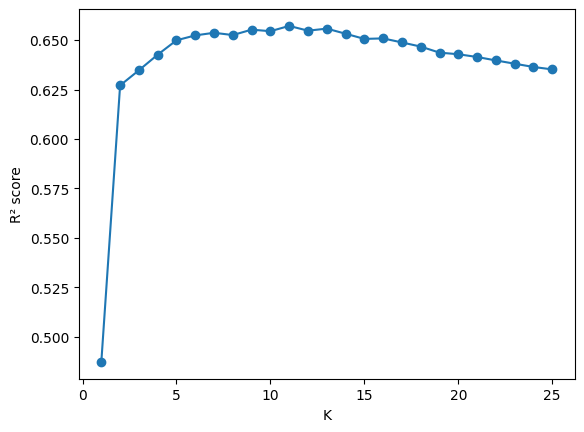

In [51]:
import matplotlib.pyplot as plt

plt.plot(range(1, 26), scores, marker="o")
plt.xlabel("K")
plt.ylabel("R² score")
plt.show()

❓ Which value of K produces the best performance? Save your answer under variable name `best_k`.

In [52]:
best_k = 11

<details>
<summary> 👉 Solution 👈</summary>
    
By looking at your graph, you should see that the score stops increasing around k = 5 and the maximum score is reached for k = 11.

</details>



❓ What is you interpretation of the poor performance of the model for values $k$ < 5?

<details>
<summary> 👉 Solution 👈</summary>
    
When K is too small, the model will tend to overfit to the training set. It will focus on too few points to be able to generalize well. Increasing K will give the model more examples to base its predictions on.

</details>



### 🧪 Check your code

In [53]:
from nbresult import ChallengeResult

result = ChallengeResult('optimal_k',
                         optimal_k = best_k)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/nada/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
rootdir: /home/nada/code/Nadafarj/05-ML/03-Performance-metrics/data-knn/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_optimal_k.py::TestOptimal_k::test_optimal_K_around_10 PASSED        [100%]

============================== 1 passed in 0.03s ===============================


💯 You can commit your code:

git add tests/optimal_k.pickle

git commit -m 'Completed optimal_k step'

git push origin master



In [54]:
!git add tests/optimal_k.pickle

!git commit -m 'Completed optimal_k step'

!git push origin master


[master 2f12685] Completed optimal_k step
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 tests/optimal_k.pickle
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 8 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 445 bytes | 445.00 KiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To github.com:Nadafarj/data-knn.git
   c3438f9..2f12685  master -> master


# Overfitting a KNN 

💡 When the parameter K of KNNs is too small, there is a risk of overfitting the training set and not being able to generalize well. 

👇 Plot the learning curves of a KNN with parameter K=2.

In [57]:
model = KNeighborsRegressor(n_neighbors=2)

In [58]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_rescaled,
    y,
    cv=5,
    scoring="r2"
)

In [59]:
train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)

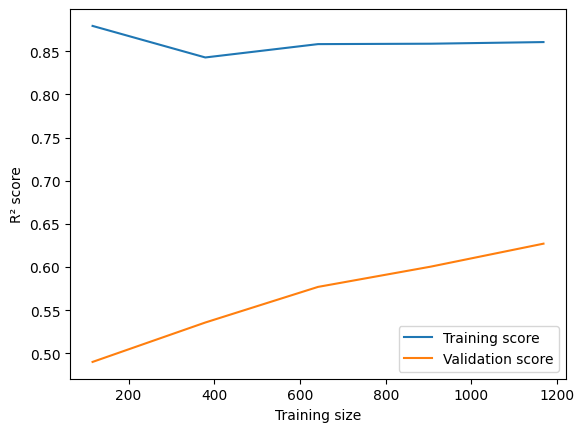

In [60]:
plt.plot(train_sizes, train_scores_mean, label="Training score")
plt.plot(train_sizes, val_scores_mean, label="Validation score")

plt.xlabel("Training size")
plt.ylabel("R² score")
plt.legend()
plt.show()

👉 You should observe a high training score, but a low testing score. ⚠️ Overfitting alert ⚠️ This is due to a parameter K that is too low.

# Ideal K

👇 This time, plot the learning curves for the ideal K value you found in the "Optimizing $k$" section.

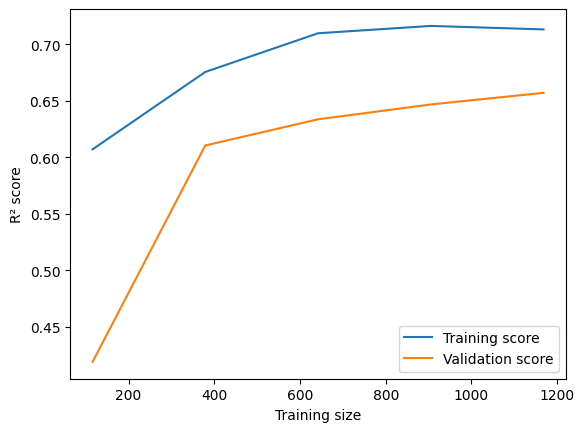

In [61]:
model = KNeighborsRegressor(n_neighbors=best_k)

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_rescaled,
    y,
    cv=5,
    scoring="r2"
)

train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_scores_mean, label="Training score")
plt.plot(train_sizes, val_scores_mean, label="Validation score")

plt.xlabel("Training size")
plt.ylabel("R² score")
plt.legend()
plt.show()

👉 The curves should be close to converging, which indicates that the model is overfitting less and generalizing better.

💡 There are two key elements to remember when modelling with KNN models:  
    1. Distance-based algorithms are extremely sensitive to the scale of features  
    2. K must be tuned: it controls the tradeoff between performance, generalization, and overfitting

❓ What is the average difference between actual price and predicted price of the optimized KNN model? Compute your answer and save it under variable name `price_error`

<details>
<summary> 💡 Hint </summary>
    
The metric you should calculate is the **Negative Mean Absolute Error (MAE)**.

</details>

In [63]:
model = KNeighborsRegressor(n_neighbors=best_k)

mae_scores = cross_val_score(
    model,
    X_rescaled,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

In [65]:
price_error = -mae_scores.mean()
price_error

30823.53430884184

### 🧪 Check your code

In [66]:
from nbresult import ChallengeResult

result = ChallengeResult('price_error',
                         error = price_error)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/nada/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
rootdir: /home/nada/code/Nadafarj/05-ML/03-Performance-metrics/data-knn/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_price_error.py::TestPrice_error::test_price_error_range PASSED      [100%]

============================== 1 passed in 0.48s ===============================


💯 You can commit your code:

git add tests/price_error.pickle

git commit -m 'Completed price_error step'

git push origin master



In [67]:
!git add tests/price_error.pickle

!git commit -m 'Completed price_error step'

!git push origin master

[master 4bc61ec] Completed price_error step
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 tests/price_error.pickle
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 8 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 535 bytes | 535.00 KiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To github.com:Nadafarj/data-knn.git
   2f12685..4bc61ec  master -> master


# Model Selection

❓ Which of those two models would you chose to perform the task of predicting house prices:
- The KNN model you just tuned
- A Linear Regression model

Save your answer as a string under variable name `best_model` as either "KNN" or "LinearReg".

<details>
<summary> 💡 Hint </summary>
    
To chose either or, you'll have to evaluate the score of a Linear Regression on the same task and compare it to the score of the KNN. Make sure you are comparing the same metrics!!

</details>




In [70]:
linear_model = LinearRegression()

linear_score = cross_val_score(
    linear_model,
    X_rescaled,
    y,
    cv=5,
    scoring="r2"
).mean()

linear_score

0.5944790982110585

In [75]:
best_model  = "KNN"

knn_score = cross_val_score(
    knn_model,
    X_rescaled,
    y,
    cv=5,
    scoring="r2"
).mean()

print("Linear Regression:", linear_score)
print("KNN:", knn_score)

Linear Regression: 0.5944790982110585
KNN: 0.6571704043326225


💡 When comparing either metric of both models, the KNN model should outperform the Linear Regression. This could be due to its ability to capture non-linear patterns in the data.

### 🧪 Check your code

In [76]:
from nbresult import ChallengeResult

result = ChallengeResult('best_model',
                         model = best_model)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/nada/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
rootdir: /home/nada/code/Nadafarj/05-ML/03-Performance-metrics/data-knn/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_best_model.py::TestBest_model::test_best_model PASSED               [100%]

============================== 1 passed in 0.03s ===============================


💯 You can commit your code:

git add tests/best_model.pickle

git commit -m 'Completed best_model step'

git push origin master



In [77]:
!git add tests/best_model.pickle

!git commit -m 'Completed best_model step'

!git push origin master


[master 1fcfd5d] Completed best_model step
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 tests/best_model.pickle
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 8 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 451 bytes | 451.00 KiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To github.com:Nadafarj/data-knn.git
   4bc61ec..1fcfd5d  master -> master


# 🏁